# 04 — Exposure sensitivity analysis

This notebook visualizes the single-exposure-family sensitivity models. It helps assess whether the risk surface or model fit changes when considering water, mines/metals, brick kilns, or RETC features separately.

In [1]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# This lets the notebook work whether it is launched from the project root or from notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)


def read_json(path):
    path = Path(path)
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing expected file: {path}")
    return path


def load_csv(relative_path, **kwargs):
    path = require_file(OUTPUTS / relative_path)
    return pd.read_csv(path, **kwargs)


def savefig(name):
    path = FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved figure: {path}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs folder: {OUTPUTS}")


Project root: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project
Outputs folder: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs


## Load sensitivity outputs

In [2]:

metrics = load_csv("sensitivity_single_family_metrics.csv")
summary = load_csv("sensitivity_single_family_model_summary.csv")
rankings = load_csv("sensitivity_single_family_rankings.csv")
feature_filter = load_csv("feature_filter_report.csv")

metrics.head()


,exposure_family,n_features,features,model_type,aic,bic,llf,fit_warnings,top_k_geo_ids
0,ambientalagua,3,"ambientalagua_kernel_intensity, ambientalagua_...",discrete_negative_binomial_estimated_dispersion,334.123545,348.424904,-160.061772,NaN,"24030, 24019, 24004, 24028, 24024, 24013, 2404..."
1,ambientalminasmetales,2,"ambientalminasmetales_kernel_intensity, ambien...",discrete_negative_binomial_estimated_dispersion,334.480589,346.738896,-161.240294,NaN,"24030, 24019, 24004, 24028, 24008, 24035, 2404..."
2,ambientalladrilleras,2,"ambientalladrilleras_kernel_intensity, ambient...",discrete_negative_binomial_estimated_dispersion,336.602526,348.860834,-162.301263,NaN,"24030, 24019, 24004, 24028, 24035, 24024, 2401..."
3,ambientalretc,4,"ambientalretc_kernel_intensity, ambientalretc_...",discrete_negative_binomial_estimated_dispersion,337.728527,354.072937,-160.864264,NaN,"24019, 24028, 24030, 24004, 24013, 24045, 2402..."


## Compare model fit by exposure family

,exposure_family,n_features,aic,bic,llf,model_type
0,ambientalagua,3,334.123545,348.424904,-160.061772,discrete_negative_binomial_estimated_dispersion
1,ambientalminasmetales,2,334.480589,346.738896,-161.240294,discrete_negative_binomial_estimated_dispersion
2,ambientalladrilleras,2,336.602526,348.860834,-162.301263,discrete_negative_binomial_estimated_dispersion
3,ambientalretc,4,337.728527,354.072937,-160.864264,discrete_negative_binomial_estimated_dispersion


Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\04_single_family_aic.png


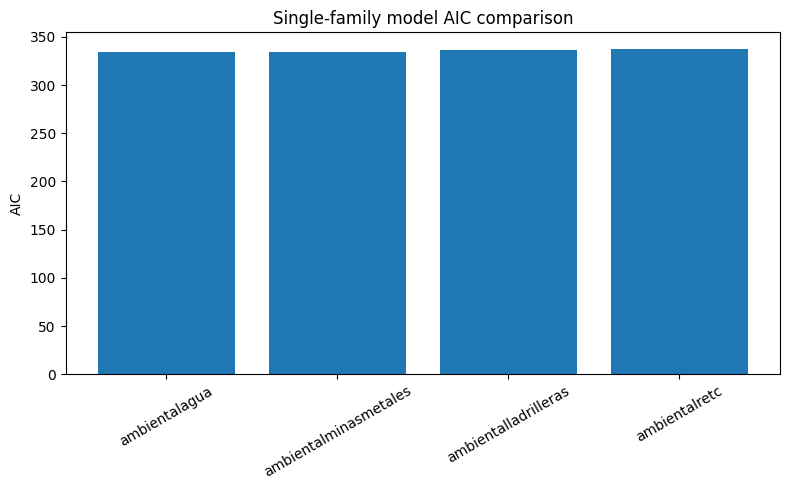

In [3]:

metrics_sorted = metrics.sort_values("aic")
display(metrics_sorted[["exposure_family", "n_features", "aic", "bic", "llf", "model_type"]])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(metrics_sorted["exposure_family"], metrics_sorted["aic"])
ax.set_ylabel("AIC")
ax.set_title("Single-family model AIC comparison")
ax.tick_params(axis="x", rotation=30)
savefig("04_single_family_aic.png")
plt.show()


## Feature filtering decisions

In [4]:

reason_col = "reason" if "reason" in feature_filter.columns else "decision"
feature_filter.groupby(reason_col).size().rename("n_features").reset_index().sort_values("n_features", ascending=False)


,reason,n_features
1,passes_filters,11
0,constant_or_all_zero,5
2,too_sparse_nonzero_lt_5,4


In [5]:

# Inspect kept/dropped features by family.
feature_filter.head(30)


,feature,status,reason,nonzero_count,nunique
0,ambientalagua_kernel_intensity,keep,passes_filters,58,58
1,ambientalagua_nearest_source_m,keep,passes_filters,58,58
2,ambientalagua_count_within_1000m,drop,constant_or_all_zero,0,1
3,ambientalagua_count_within_5000m,drop,too_sparse_nonzero_lt_5,4,3
4,ambientalagua_count_within_10000m,keep,passes_filters,11,5
5,ambientalladrilleras_kernel_intensity,keep,passes_filters,58,58
6,ambientalladrilleras_nearest_source_m,keep,passes_filters,58,58
7,ambientalladrilleras_count_within_1000m,drop,too_sparse_nonzero_lt_5,1,2
8,ambientalladrilleras_count_within_5000m,drop,too_sparse_nonzero_lt_5,2,3
9,ambientalladrilleras_count_within_10000m,drop,too_sparse_nonzero_lt_5,4,5


## Top-risk municipalities by exposure-family model

In [6]:

# Show the top 10 for each family if the rankings table has rank information.
rank_cols = [c for c in ["exposure_family", "rank", "geo_id", "predicted_rate_per_100k"] if c in rankings.columns]
if "rank" in rankings.columns:
    display(rankings.sort_values(["exposure_family", "rank"])[rank_cols].head(60))
else:
    display(rankings.head(60))


,exposure_family,geo_id,predicted_count,predicted_rate_per_100k
0,ambientalagua,24030,6.310624,262.069114
1,ambientalagua,24019,6.070610,222.938310
2,ambientalagua,24004,4.396690,218.089773
3,ambientalagua,24028,777.088799,164.983153
4,ambientalagua,24024,81.853286,160.811957
5,ambientalagua,24013,141.734483,152.387923
6,ambientalagua,24043,6.446608,151.827783
7,ambientalagua,24045,10.121640,141.127163
8,ambientalagua,24027,7.255000,137.561632
9,ambientalagua,24035,230.636820,135.513276


## Overlap of top-10 lists across exposure families

In [7]:

if "rank" in rankings.columns:
    top = rankings[rankings["rank"] <= 10].copy()
else:
    top = rankings.copy()
    top["rank"] = top.groupby("exposure_family").cumcount() + 1
    top = top[top["rank"] <= 10]

overlap = pd.crosstab(top["geo_id"].astype(str), top["exposure_family"])
overlap["n_families_top10"] = overlap.sum(axis=1)
overlap = overlap.sort_values("n_families_top10", ascending=False)
overlap.head(20)


exposure_family,ambientalagua,ambientalladrilleras,ambientalminasmetales,ambientalretc,n_families_top10
geo_id,,,,,
24004,1,1,1,1,4
24013,1,1,1,1,4
24019,1,1,1,1,4
24028,1,1,1,1,4
24043,1,1,1,1,4
24027,1,1,1,1,4
24030,1,1,1,1,4
24008,0,1,1,1,3
24035,1,1,1,0,3


Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\04_top10_overlap_by_family.png


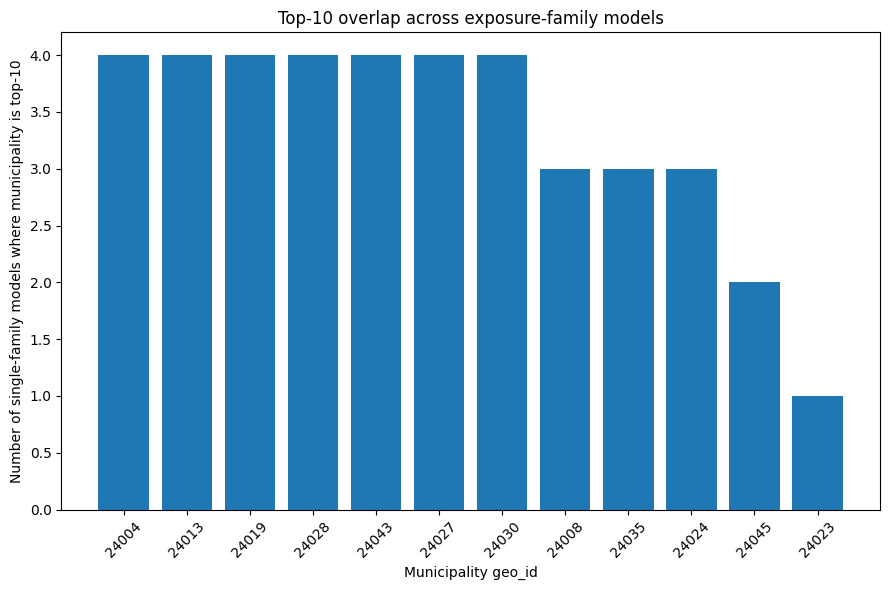

In [8]:

plot_df = overlap.head(20).copy()
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(plot_df.index.astype(str), plot_df["n_families_top10"])
ax.set_xlabel("Municipality geo_id")
ax.set_ylabel("Number of single-family models where municipality is top-10")
ax.set_title("Top-10 overlap across exposure-family models")
ax.tick_params(axis="x", rotation=45)
savefig("04_top10_overlap_by_family.png")
plt.show()


## Coefficients within each single-family model

Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\04_coefficients_ambientalagua.png


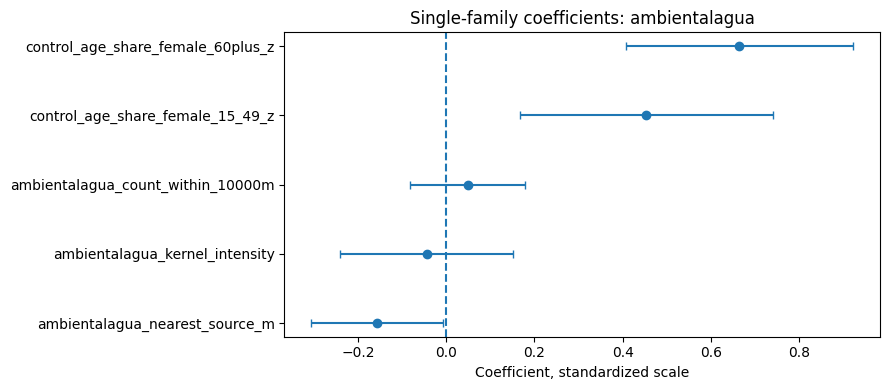

Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\04_coefficients_ambientalladrilleras.png


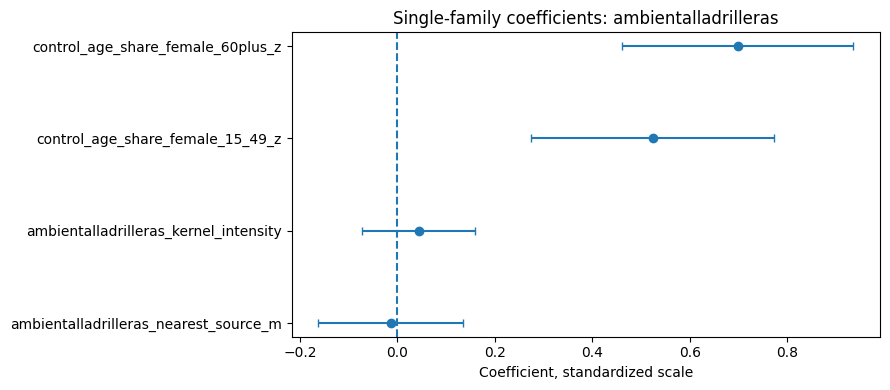

Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\04_coefficients_ambientalminasmetales.png


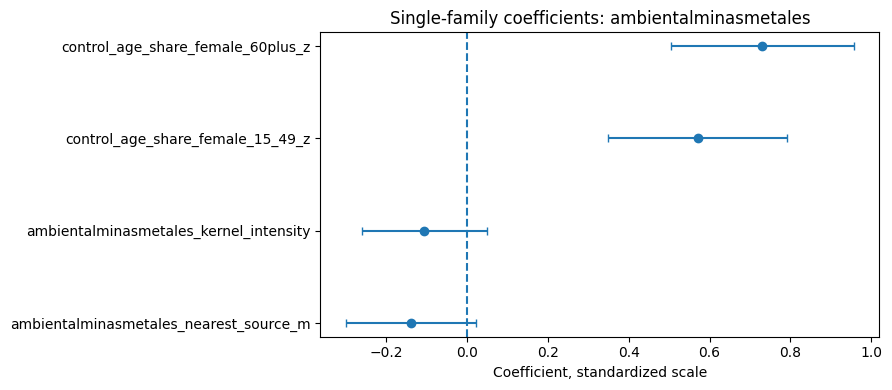

Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\04_coefficients_ambientalretc.png


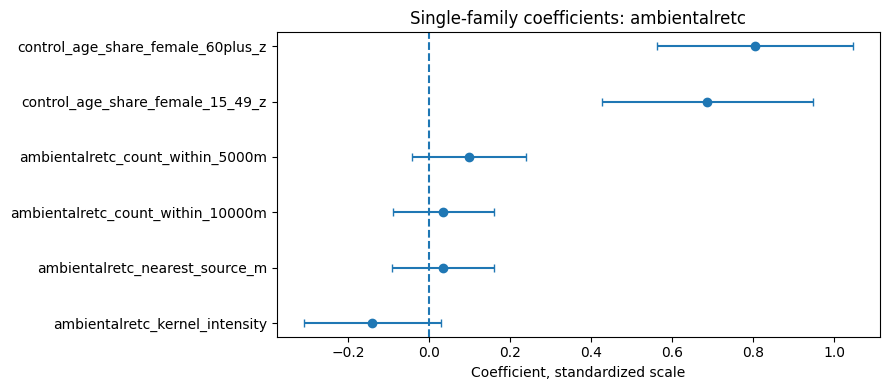

In [9]:

coef_df = summary[~summary["term"].isin(["const", "alpha"])].copy()
coef_df = coef_df.dropna(subset=["coef", "ci_lower", "ci_upper"])

for family, fam_df in coef_df.groupby("exposure_family"):
    fam_df = fam_df.sort_values("coef")
    fig, ax = plt.subplots(figsize=(9, max(4, len(fam_df) * 0.4)))
    x = fam_df["coef"]
    xerr = np.vstack([x - fam_df["ci_lower"], fam_df["ci_upper"] - x])
    ax.errorbar(x, fam_df["term"], xerr=xerr, fmt="o", capsize=3)
    ax.axvline(0, linestyle="--")
    ax.set_xlabel("Coefficient, standardized scale")
    ax.set_title(f"Single-family coefficients: {family}")
    savefig(f"04_coefficients_{family}.png")
    plt.show()


## Interpretation reminder

A lower AIC suggests a better exploratory fit, but small AIC differences are not decisive. These sensitivity models are for robustness checks, not causal claims.